In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [59]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [60]:
print(df.shape)

(100000, 9)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [62]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


EDA

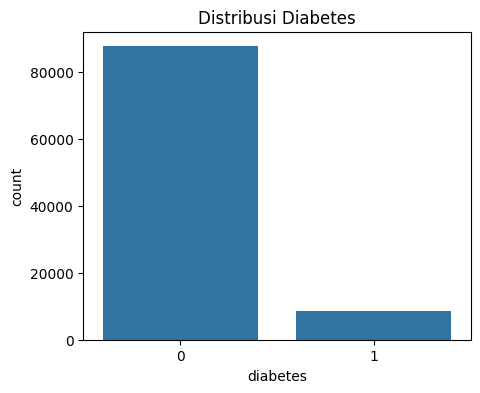

In [66]:
# DISTRIBUSI TARGET
plt.figure(figsize=(5,4))

sns.countplot(
    x='diabetes',
    data=df
)

plt.title("Distribusi Diabetes")
plt.show()

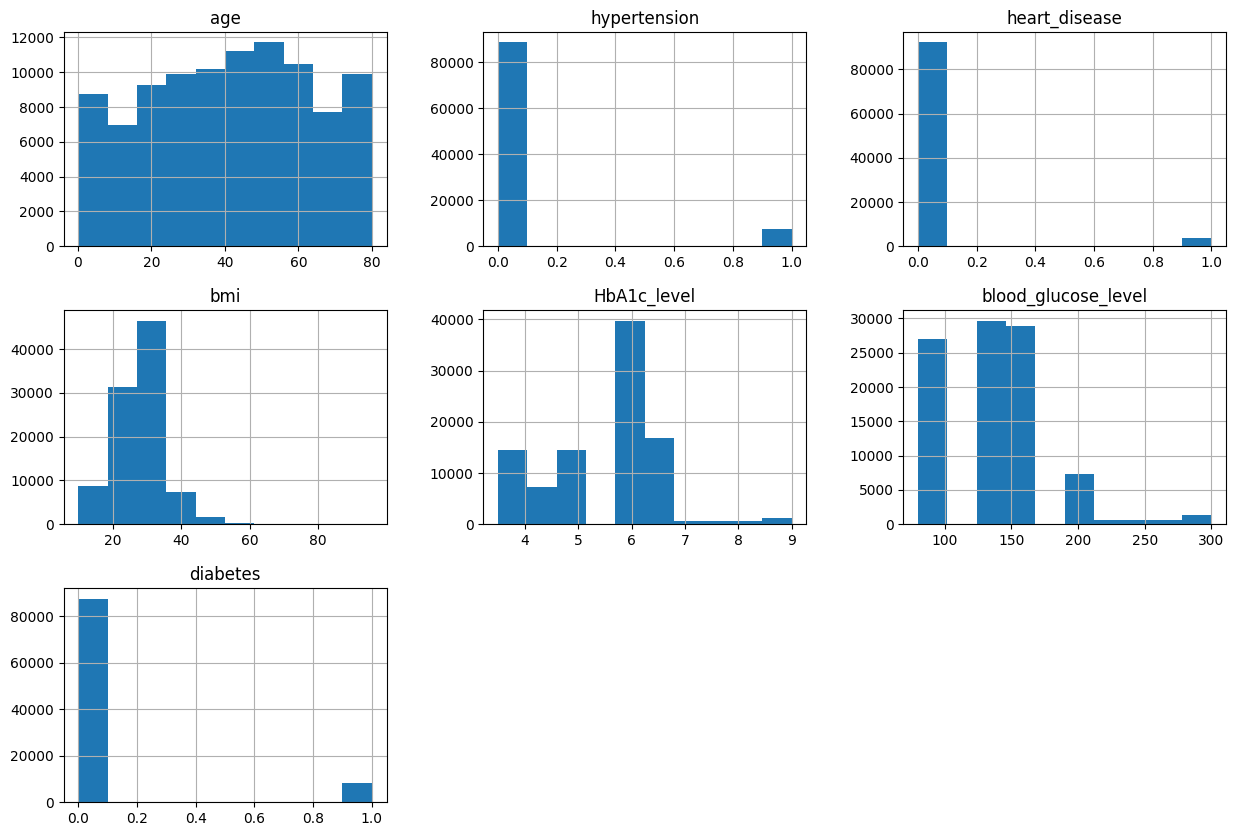

In [67]:
# HISTOGRAM
df.hist(
    figsize=(15,10)
)

plt.show()

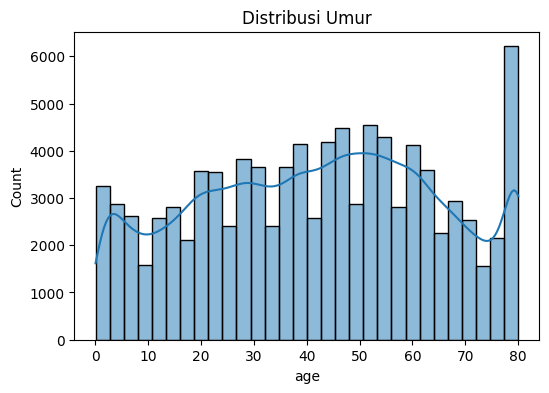

In [95]:
# Distribusi Umur
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='age',
    bins=30,
    kde=True
)

plt.title('Distribusi Umur')
plt.show()

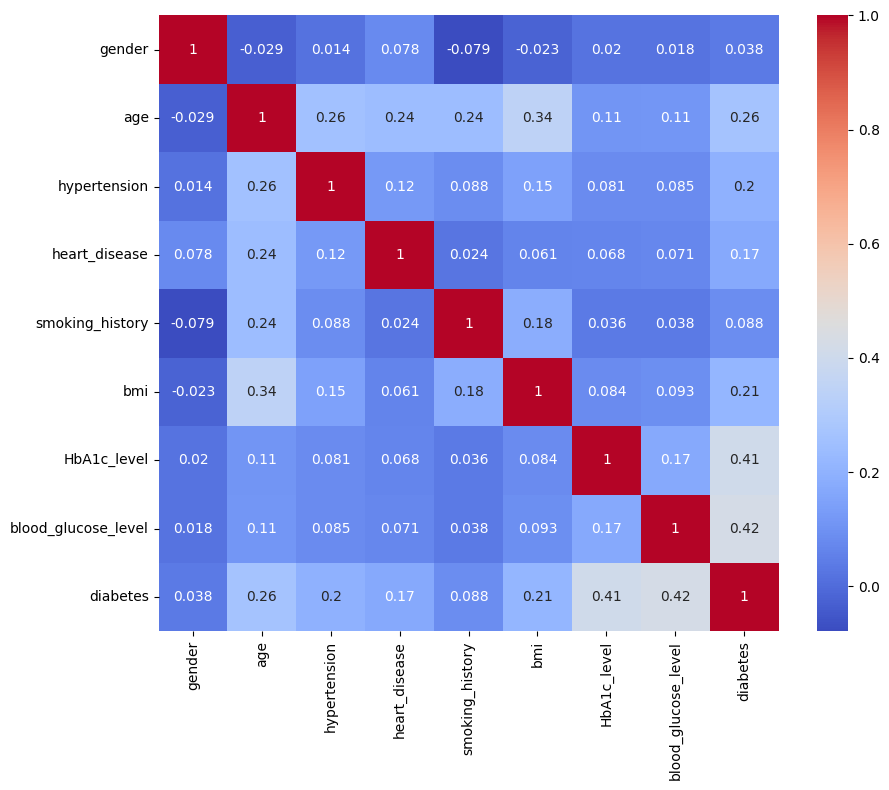

In [97]:
# heatmap korelasi
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

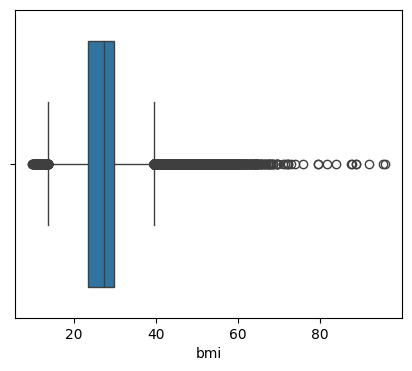

In [71]:
# Boxplot BMI
plt.figure(figsize=(5,4))

sns.boxplot(
    x=df['bmi']
)

plt.show()

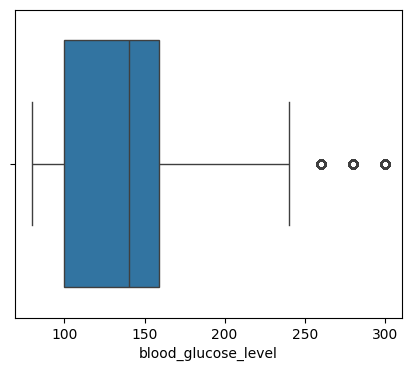

In [73]:
# Boxplot Glucose
plt.figure(figsize=(5,4))

sns.boxplot(
    x=df['blood_glucose_level']
)

plt.show()

Preprocessing

In [63]:
# Cek missing value
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [91]:
print("Duplicate :",df.duplicated().sum())

Duplicate : 0


In [92]:
# Hapus duplikat
df=df.drop_duplicates()

In [96]:
# Encoding data kategorikal
le = LabelEncoder()

df['gender']=le.fit_transform(df['gender'])
df['smoking_history']=le.fit_transform(df['smoking_history'])


In [74]:
# Pisah Fitur dan Target
X = df.drop('diabetes',axis=1)

y = df['diabetes']

In [75]:
# Train split / pembagian data latih dan data uji
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [76]:
# Penyeimbangan data menggunakan SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote,y_train_smote = smote.fit_resample(

    X_train,
    y_train

)
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

diabetes
0    70130
1     6786
Name: count, dtype: int64

diabetes
0    70130
1    70130
Name: count, dtype: int64


In [77]:
# Scaling / Standardisasi data
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(

    X_train_smote

)

X_test = scaler.transform(

    X_test
)

Modeling

In [78]:
# Buat Model
models = {


'Logistic Regression':

LogisticRegression(

max_iter=1000
),

'Decision Tree':

DecisionTreeClassifier(

random_state=42
),

'Random Forest':

RandomForestClassifier(

random_state=42
),

'KNN':

KNeighborsClassifier(),

'XGBoost':

XGBClassifier(

eval_metric='logloss',

random_state=42
)

}

Training Model dan Evaluasi

In [94]:
# Training dan Evaluasi
results = []

for name,model in models.items():

    model.fit(

        X_train_smote,

        y_train_smote

    )

    y_pred = model.predict(

        X_test

    )

    y_prob = model.predict_proba(

        X_test

    )[:,1]

    accuracy = accuracy_score(

        y_test,
        y_pred
    )

    precision = precision_score(

        y_test,
        y_pred
    )

    recall = recall_score(

        y_test,
        y_pred
    )

    f1 = f1_score(

        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(

        y_test,
        y_prob
    )
    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ])

In [80]:
# tabel hasil
results_df = pd.DataFrame(

    results,

    columns=[

        'Model',

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score',

        'ROC AUC'

    ]

)
results_df = results_df.sort_values(

    by='F1 Score',

    ascending=False

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.965107,0.855656,0.727005,0.786101,0.974239
2,Random Forest,0.956526,0.758413,0.744104,0.751190,0.963647
1,Decision Tree,0.946178,0.676079,0.748231,0.710327,0.857214
3,KNN,0.896048,0.450635,0.815448,0.580483,0.926757
0,Logistic Regression,0.879615,0.412397,0.859080,0.557277,0.954759


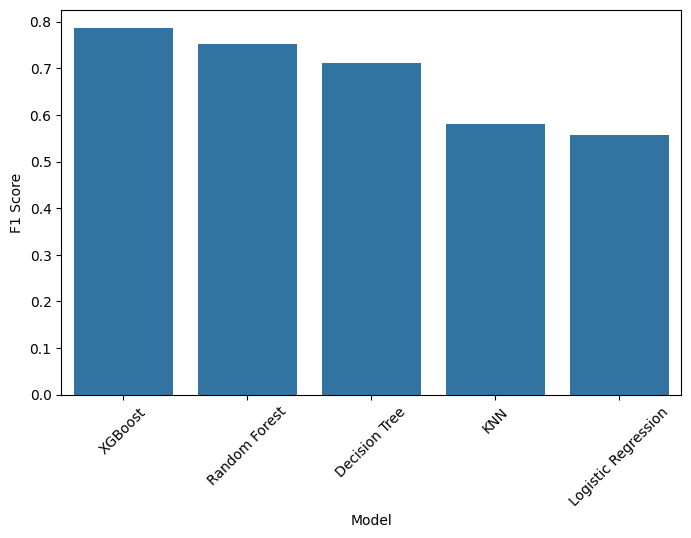

In [81]:
# Visualisasi perbandingan
plt.figure(figsize=(8,5))

sns.barplot(

    data=results_df,

    x='Model',

    y='F1 Score'

)

plt.xticks(rotation=45)

plt.show()

Feature Importance

In [82]:
# Model terbaik
best_model = XGBClassifier(

    eval_metric='logloss',

    random_state=42

)

best_model.fit(

    X_train_smote,

    y_train_smote

)

y_pred = best_model.predict(

    X_test

)

In [84]:
# Klasifikasi report
print(

classification_report(

y_test,

y_pred

)

)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.86      0.73      0.79      1696

    accuracy                           0.97     19230
   macro avg       0.91      0.86      0.88     19230
weighted avg       0.96      0.97      0.96     19230



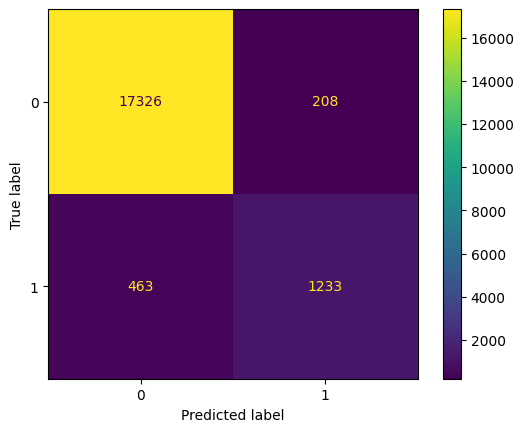

In [86]:
# Confussion matrix
cm = confusion_matrix(

    y_test,

    y_pred

)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)


disp.plot()


plt.show()

In [87]:
# Feature importance
importance = pd.DataFrame({


'Feature':X.columns,


'Importance':
best_model.feature_importances_


})


importance = importance.sort_values(

    by='Importance',

    ascending=False

)


importance

,Feature,Importance
6,HbA1c_level,0.589651
7,blood_glucose_level,0.293352
1,age,0.056586
5,bmi,0.022040
4,smoking_history,0.015962
0,gender,0.011730
2,hypertension,0.005405
3,heart_disease,0.005273


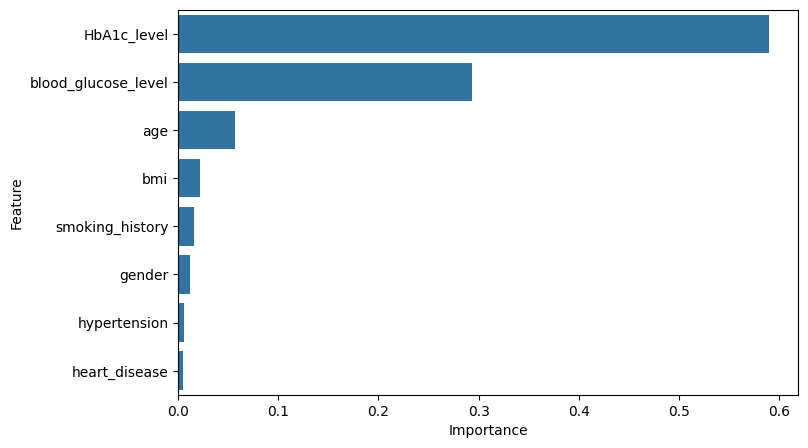

In [88]:
# Visualisasi feature importance
plt.figure(figsize=(8,5))


sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.show()

In [89]:
# Kesimpulan
print("Model terbaik:")

print(

results_df.iloc[0]

)

Model terbaik:
Model         XGBoost
Accuracy     0.965107
Precision    0.855656
Recall       0.727005
F1 Score     0.786101
ROC AUC      0.974239
Name: 4, dtype: object
